### 1. Environment Setup
We will install and import the necessary libraries for deep learning, image processing, and visualization.

In [ ]:
# Install necessary libraries if they are not already available
# !pip install tensorflow opencv-python numpy matplotlib seaborn scikit-learn

import tensorflow as tf # Deep learning framework
import cv2               # Image processing library (OpenCV)
import numpy as np        # Numerical operations and array handling
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns     # Advanced data visualization based on matplotlib
import os                # Operating system interface (file handling)
from sklearn.model_selection import train_test_split # Splitting data into train/test sets

# Print the current TensorFlow version to ensure compatibility
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [ ]:
# Check if a GPU is available for faster training
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Setting memory growth to avoid allocating all GPU memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found. Training might be slow. Please go to Edit > Notebook settings and select 'T4 GPU'.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Data Loading and Preprocessing
In this section, we define the parameters for our images and create a function to load them from a directory.

In [ ]:
# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

def preprocess_image(image_path):
    # Load image using OpenCV
    img = cv2.imread(image_path)
    # Convert color from BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Resize image to the required dimensions
    img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))
    # Normalize pixel values to be between 0 and 1
    img = img / 255.0
    return img

print("Preprocessing functions defined successfully.")

Preprocessing functions defined successfully.


### 3. Model Architecture
We will build a Convolutional Neural Network (CNN) using Transfer Learning. This approach is effective for medical imaging where data can be limited.

In [ ]:
# Import layers and models from Keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2

def build_model(input_shape=(224, 224, 3)):
    # Load pre-trained MobileNetV2 without the top classification layer
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the base model to keep pre-trained weights
    base_model.trainable = False

    # Create a new model on top
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Global Average Pooling to reduce dimensions
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout layer for regularization to prevent overfitting
    x = layers.Dropout(0.2)(x)

    # Output layer: 1 unit with Sigmoid activation for binary classification (Tumor vs No Tumor)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    # Compile the model with Adam optimizer and Binary Crossentropy loss
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate and summarize the model
brain_tumor_model = build_model()
brain_tumor_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4. Explainability with Grad-CAM
To make our model explainable, we use Grad-CAM to visualize which parts of the MRI scan contribute most to the model's decision.

In [ ]:
def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important this channel is"
    # with regard to the top predicted class, then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

print("Grad-CAM explainability function defined.")

Grad-CAM explainability function defined.


### 5. Visualization Helper
This final helper function will overlay the generated heatmap onto the original MRI image for visual inspection.

In [ ]:
def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    jet_heatmap = np.uint8(jet_heatmap * 255)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

    # Display the result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original MRI")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Explainable Heatmap (Grad-CAM)")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

print("Visualization tools are ready. You can now load your dataset and start training!")

Visualization tools are ready. You can now load your dataset and start training!


### 6. Loading Dataset from Google Drive
We will mount your Google Drive and inspect the dataset structure for the four classes: glioma, meningioma, pituitary, and notumor.

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# The base path provided by user
base_path = '/content/drive/MyDrive/Brain Tumor'

# Function to search for the specific class folders inside the base path
def find_dataset_folders(root_dir, target_classes):
    found_paths = {}
    for root, dirs, files in os.walk(root_dir):
        for d in dirs:
            if d.lower() in target_classes:
                found_paths[d.lower()] = os.path.join(root, d)
    return found_paths

classes = ['glioma', 'meningioma', 'pituitary', 'notumor']
found_folders = find_dataset_folders(base_path, classes)

image_counts = {}
print(f"Searching for dataset folders in: {base_path}\n")

for label in classes:
    if label in found_folders:
        folder_path = found_folders[label]
        # Count only files to avoid counting subdirectories
        count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        image_counts[label] = count
        print(f"Found Class: {label.capitalize()} at {folder_path} | Images: {count}")
    else:
        image_counts[label] = 0
        print(f"Warning: Could not find a folder for '{label}' in the path provided.")

# Update the global path variable for future cells
if found_folders:
    # Use the parent directory of one of the found classes as the new dataset path
    dataset_path = os.path.dirname(list(found_folders.values())[0])
    print(f"\nDetected Dataset Path: {dataset_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for dataset folders in: /content/drive/MyDrive/Brain Tumor

Found Class: Glioma at /content/drive/MyDrive/Brain Tumor/BRAIN_TUMOR_DATASET/Training/glioma | Images: 1400
Found Class: Meningioma at /content/drive/MyDrive/Brain Tumor/BRAIN_TUMOR_DATASET/Training/meningioma | Images: 1400
Found Class: Pituitary at /content/drive/MyDrive/Brain Tumor/BRAIN_TUMOR_DATASET/Training/pituitary | Images: 1400
Found Class: Notumor at /content/drive/MyDrive/Brain Tumor/BRAIN_TUMOR_DATASET/Training/notumor | Images: 1400

Detected Dataset Path: /content/drive/MyDrive/Brain Tumor/BRAIN_TUMOR_DATASET/Training


/tmp/ipykernel_732/3070042661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette='viridis')


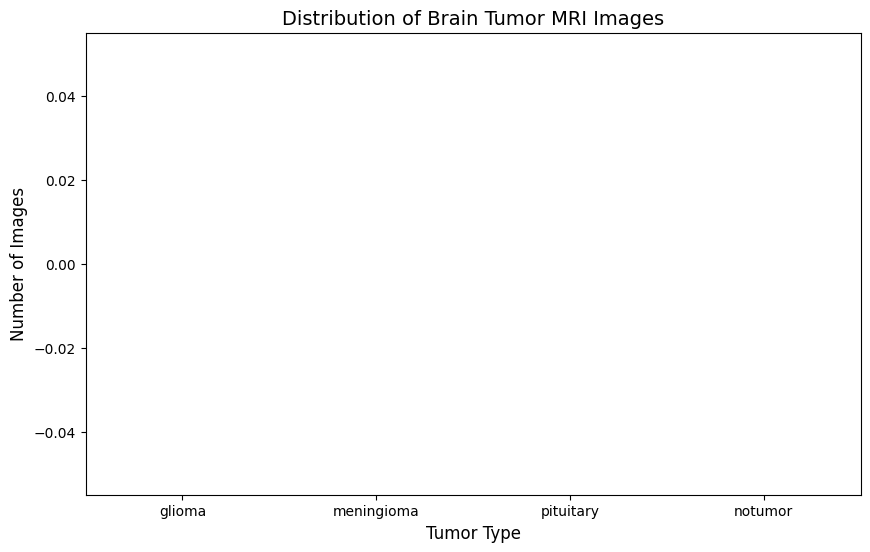

In [ ]:
# Visualize the class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette='viridis')

# Add titles and labels for clarity
plt.title('Distribution of Brain Tumor MRI Images', fontsize=14)
plt.xlabel('Tumor Type', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Display the plot
plt.show()

### 7. Data Augmentation and Generators
We use `ImageDataGenerator` to perform real-time data augmentation (like rotation and zoom) which helps the model generalize better and prevents overfitting.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an instance of ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    validation_split=0.2,    # Reserve 20% of images for validation
    rotation_range=10,       # Randomly rotate images
    zoom_range=0.1,          # Randomly zoom in/out
    horizontal_flip=True     # Flip images horizontally
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',     # Use sparse categorical for multi-class
    subset='training'
)

# Validation data generator
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


### 8. Model Training
Since we have 4 classes now, we need to adjust our model's output layer and then start training.

In [ ]:
# Re-building the model head for 4 classes instead of 1
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x) # 4 classes with Softmax

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Start Training
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10 # You can increase this for better accuracy
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2016s 14s/step - accuracy: 0.7228 - loss: 0.6919 - val_accuracy: 0.8670 - val_loss: 0.4023
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 606ms/step - accuracy: 0.8507 - loss: 0.4124 - val_accuracy: 0.8795 - val_loss: 0.3260
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 569ms/step - accuracy: 0.8607 - loss: 0.3651 - val_accuracy: 0.8813 - val_loss: 0.3151
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 567ms/step - accuracy: 0.8864 - loss: 0.3190 - val_accuracy: 0.8982 - val_loss: 0.2863
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 556ms/step - accuracy: 0.8911 - loss: 0.2982 - val_accuracy: 0.8973 - val_loss: 0.2714
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 566ms/step - accuracy: 0.8904 - loss: 0.2968 - val_accuracy: 0.9062 - val_loss: 0.2591
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 570ms/step - accuracy: 0.8940 - loss: 0.2779 - val_accuracy: 0.9107 - val_loss: 0.2597
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 571ms/step - accuracy: 0.9054 - loss: 0

### 13. EfficientNetB0 Model Construction
In this step, we use Transfer Learning with **EfficientNetB0**. We keep the 'knowledge' the model gained from the ImageNet dataset and only train the final layers to recognize our specific MRI tumor types.

In [20]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

def build_efficientnet_model(input_shape=(224, 224, 3), num_classes=4):
    # 1. Load the EfficientNetB0 model pretrained on ImageNet
    # include_top=False removes the final classification layer specific to ImageNet
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)

    # 2. Freeze the base model layers
    # This prevents the pre-trained weights from being updated during the first phase of training
    base_model.trainable = False

    # 3. Define the new architecture on top of the base model
    inputs = layers.Input(shape=input_shape)

    # Pass the inputs through the base model
    x = base_model(inputs, training=False)

    # 4. GlobalAveragePooling2D reduces the spatial dimensions (height/width) to a single vector
    x = layers.GlobalAveragePooling2D()(x)

    # 5. Add a Dense layer for learning complex patterns from the features
    x = layers.Dense(128, activation='relu')(x)

    # 6. Dropout layer randomly ignores neurons during training to prevent overfitting
    x = layers.Dropout(0.3)(x)

    # 7. Final output layer with Softmax activation for 4-class classification
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create the final Model object
    model = models.Model(inputs, outputs)

    # 8. Compile the model
    # Adam optimizer is efficient, and sparse_categorical_crossentropy matches our integer labels
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Instantiate the EfficientNetB0 model
efficientnet_model = build_efficientnet_model()

# Display the structure of the model
efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 14. Model Compilation
In this step, we configure the learning process by specifying the optimizer, loss function, and evaluation metrics.

In [21]:
# 1. Set the Optimizer to Adam for efficient weight updates
# 2. Use 'sparse_categorical_crossentropy' since our labels are integers (0, 1, 2, 3)
# 3. Track 'accuracy' to monitor performance

efficientnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 model successfully compiled with Adam optimizer and Categorical Crossentropy loss!")

EfficientNetB0 model successfully compiled with Adam optimizer and Categorical Crossentropy loss!


### 15. Training the EfficientNetB0 Model
We will now train the model using our augmented data generators. We use callbacks to monitor performance and save the best weights.

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. EarlyStopping: Stop training when validation loss stops improving for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 2. ModelCheckpoint: Save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    'best_efficientnet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 3. Start the training loop
# We use the generators we created specifically for EfficientNet (train_generator, val_generator)
history_eff = efficientnet_model.fit(
    train_generator,
    epochs=15,               # Maximum number of iterations
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint], # Attach our safety and saving tools
    verbose=1
)

print("Training process completed!")

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6932 - loss: 0.7393
Epoch 1: val_accuracy improved from None to 0.85804, saving model to best_efficientnet_model.h5



Epoch 1: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 115s 647ms/step - accuracy: 0.7837 - loss: 0.5481 - val_accuracy: 0.8580 - val_loss: 0.3666
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8548 - loss: 0.3856
Epoch 2: val_accuracy improved from 0.85804 to 0.88482, saving model to best_efficientnet_model.h5



Epoch 2: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 587ms/step - accuracy: 0.8574 - loss: 0.3854 - val_accuracy: 0.8848 - val_loss: 0.3234
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8856 - loss: 0.3095
Epoch 3: val_accuracy improved from 0.88482 to 0.89286, saving model to best_efficientnet_model.h5



Epoch 3: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 585ms/step - accuracy: 0.8757 - loss: 0.3175 - val_accuracy: 0.8929 - val_loss: 0.2881
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8934 - loss: 0.3015
Epoch 4: val_accuracy improved from 0.89286 to 0.90714, saving model to best_efficientnet_model.h5



Epoch 4: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 594ms/step - accuracy: 0.8958 - loss: 0.2870 - val_accuracy: 0.9071 - val_loss: 0.2478
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9002 - loss: 0.2454
Epoch 5: val_accuracy did not improve from 0.90714
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 590ms/step - accuracy: 0.9013 - loss: 0.2575 - val_accuracy: 0.8946 - val_loss: 0.2741
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9031 - loss: 0.2416
Epoch 6: val_accuracy did not improve from 0.90714
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 586ms/step - accuracy: 0.9047 - loss: 0.2448 - val_accuracy: 0.9045 - val_loss: 0.2505
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9101 - loss: 0.2316
Epoch 7: val_accuracy did not improve from 0.90714
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 569ms/step - accuracy: 0.9141 - loss: 0.2226 - val_accuracy: 0.9062 - val_loss: 0.2347
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0


Epoch 9: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.9295 - loss: 0.1944 - val_accuracy: 0.9241 - val_loss: 0.2065
Epoch 10/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9301 - loss: 0.1818
Epoch 10: val_accuracy improved from 0.92411 to 0.92768, saving model to best_efficientnet_model.h5



Epoch 10: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.9299 - loss: 0.1868 - val_accuracy: 0.9277 - val_loss: 0.2059
Epoch 11/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9301 - loss: 0.1825
Epoch 11: val_accuracy did not improve from 0.92768
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 574ms/step - accuracy: 0.9304 - loss: 0.1845 - val_accuracy: 0.9259 - val_loss: 0.1924
Epoch 12/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9306 - loss: 0.1762
Epoch 12: val_accuracy improved from 0.92768 to 0.92857, saving model to best_efficientnet_model.h5



Epoch 12: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.9359 - loss: 0.1670 - val_accuracy: 0.9286 - val_loss: 0.1919
Epoch 13/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9481 - loss: 0.1509
Epoch 13: val_accuracy improved from 0.92857 to 0.93661, saving model to best_efficientnet_model.h5



Epoch 13: finished saving model to best_efficientnet_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 569ms/step - accuracy: 0.9440 - loss: 0.1557 - val_accuracy: 0.9366 - val_loss: 0.1869
Epoch 14/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9500 - loss: 0.1443
Epoch 14: val_accuracy did not improve from 0.93661
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.9453 - loss: 0.1498 - val_accuracy: 0.9295 - val_loss: 0.1835
Epoch 15/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9457 - loss: 0.1404
Epoch 15: val_accuracy did not improve from 0.93661
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 576ms/step - accuracy: 0.9467 - loss: 0.1415 - val_accuracy: 0.9366 - val_loss: 0.1749
Training process completed!


### 16. Visualizing Training Performance
We will plot the accuracy and loss curves to analyze if the model is learning correctly or overfitting.

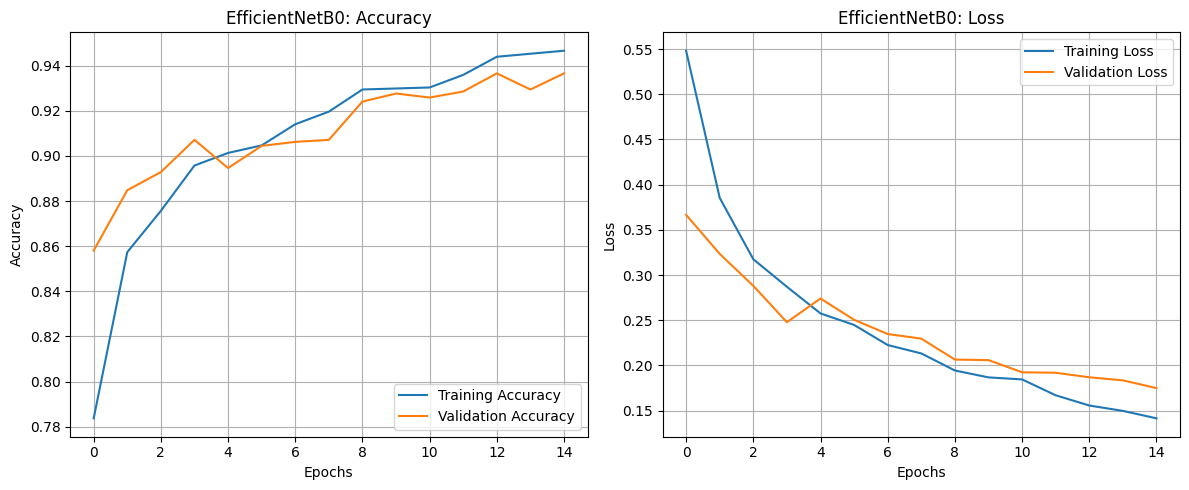

In [23]:
# 1. Extract values from the history object
acc = history_eff.history['accuracy']
val_acc = history_eff.history['val_accuracy']
loss = history_eff.history['loss']
val_loss = history_eff.history['val_loss']
epochs_range = range(len(acc))

# 2. Create the plots
plt.figure(figsize=(12, 5))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('EfficientNetB0: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('EfficientNetB0: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### 17. Model Evaluation on Test Data
We will evaluate the best saved version of our model using the independent testing set to understand its real-world performance.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# 1. Load the best weights saved during training
efficientnet_model.load_weights('best_efficientnet_model.h5')

# 2. Generate predictions for the test set
# We ensure shuffle=False in the generator to match predictions with true labels
test_gen.reset()
predictions = efficientnet_model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

# 3. Calculate Overall Accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# 4. Generate a detailed Classification Report (Precision, Recall, F1)
class_names = list(test_gen.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 522s 11s/step
Test Accuracy: 87.94%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.69      0.79       400
  meningioma       0.81      0.84      0.82       400
     notumor       0.94      0.99      0.97       400
   pituitary       0.85      1.00      0.92       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



### 18. Confusion Matrix Visualization
The Confusion Matrix helps us visualize the errors made by the model for each specific category.

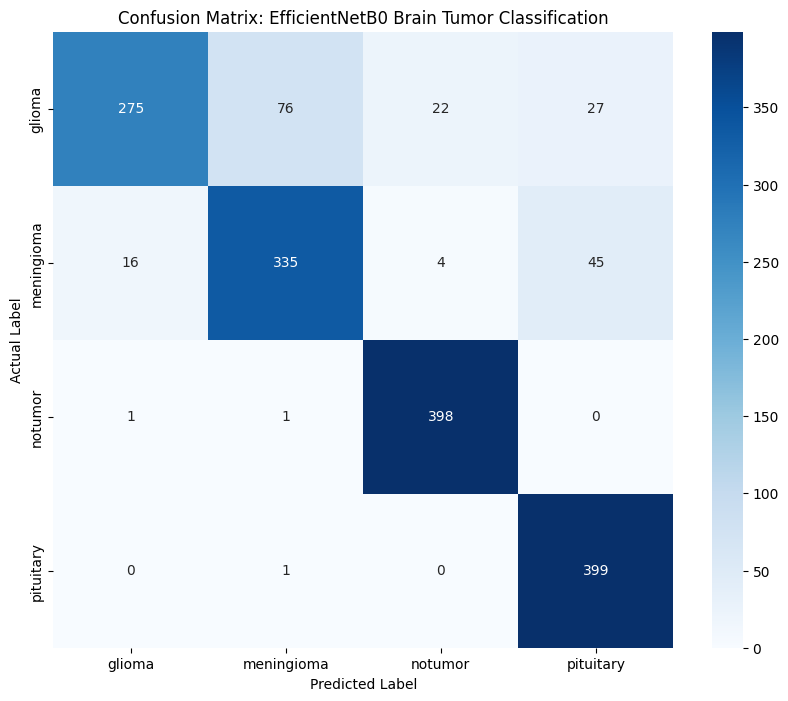

In [25]:
# 1. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Plot the matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix: EfficientNetB0 Brain Tumor Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 19. Visualizing Sample Predictions
We'll pick random images from the test set to see how the model performs on individual scans, displaying the predicted class and the confidence level.

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


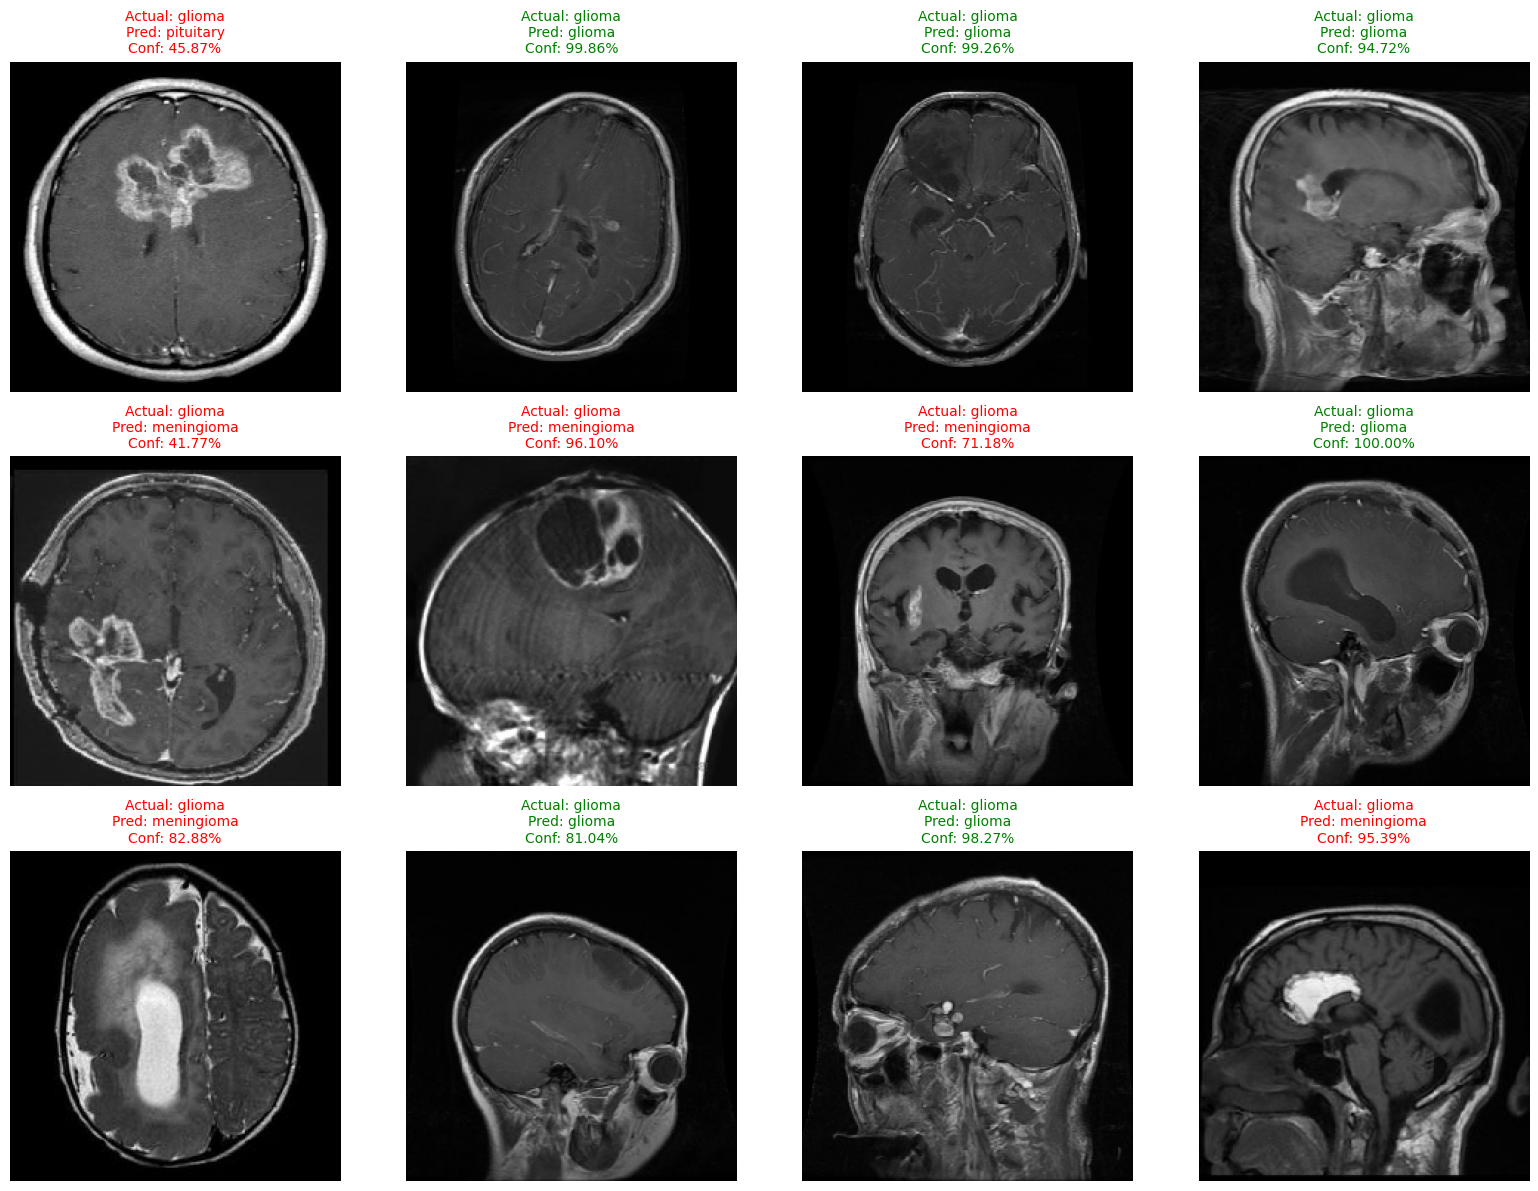

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select a batch of images from the test generator
test_gen.reset()
x_test, y_test = next(test_gen)

# 2. Generate predictions for this batch
preds = efficientnet_model.predict(x_test)

# 3. Visualize the results
plt.figure(figsize=(16, 12))

# We will display the first 12 images from the batch
for i in range(12):
    plt.subplot(3, 4, i + 1)

    # EfficientNet preprocessing might shift values; we normalize for display
    display_img = x_test[i]
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())

    # Get the true label and the predicted label
    actual_label = class_names[int(y_test[i])]
    pred_idx = np.argmax(preds[i])
    predicted_label = class_names[pred_idx]
    confidence = preds[i][pred_idx] * 100

    # Set color: green if correct, red if incorrect
    color = 'green' if predicted_label == actual_label else 'red'

    plt.imshow(display_img)
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}\nConf: {confidence:.2f}%", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


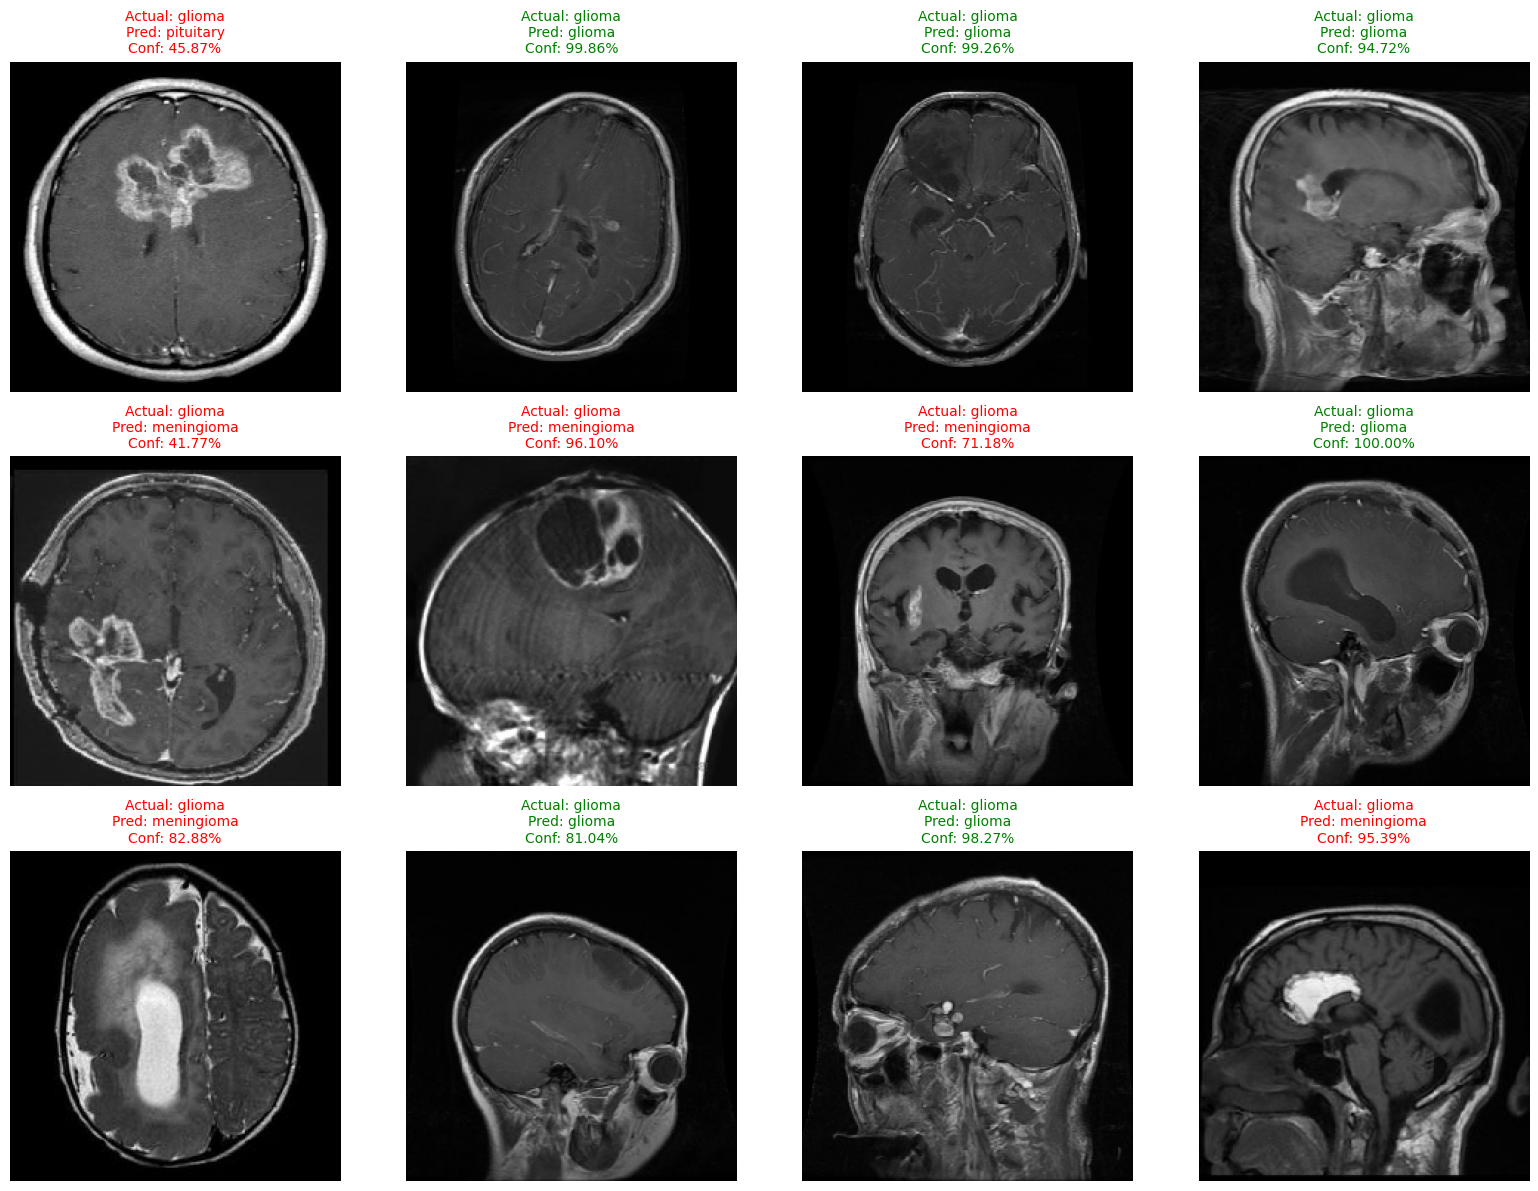

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Reset the test generator and get a random batch
test_gen.reset()
x_batch, y_batch = next(test_gen)

# 2. Get model predictions for the batch
preds = efficientnet_model.predict(x_batch)

# 3. Plot the results
plt.figure(figsize=(16, 12))

# Display 12 samples
for i in range(12):
    plt.subplot(3, 4, i + 1)

    # Normalize EfficientNet preprocessed images for display (0-1 range)
    img_display = x_batch[i]
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    # Identify labels and confidence
    actual_label = class_names[int(y_batch[i])]
    pred_idx = np.argmax(preds[i])
    predicted_label = class_names[pred_idx]
    confidence = preds[i][pred_idx] * 100

    # Green if correct, Red if incorrect
    title_color = "green" if predicted_label == actual_label else "red"

    plt.imshow(img_display)
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}\nConf: {confidence:.2f}%", color=title_color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 20. Grad-CAM Implementation for EfficientNetB0

Grad-CAM works by looking at the gradients of the target class flowing into the final convolutional layer of the model. This tells us which parts of the image were most 'important' for the final prediction.

First, we need to identify the last convolutional layer of our EfficientNetB0 model. In Keras's implementation, this is typically named `'top_activation'`.

In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Create a model that maps the input image to the activations of the last conv layer
    # and the final output predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Run the image through this new model and record the gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # Handle different output structures (EfficientNet base vs full model)
        if isinstance(preds, (list, tuple)):
             preds = preds[0]

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        # Use tf.gather to avoid indexing issues with varying shapes
        class_channel = tf.gather(preds[0], pred_index)

    # 3. Calculate the gradient of the predicted class with respect to the output of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Pool the gradients across all channels to find the importance of each feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply each channel in the feature map by its importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Apply ReLU and normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

print("Grad-CAM generator function updated and fixed.")

Grad-CAM generator function updated and fixed.


In [29]:
def save_and_display_gradcam(img, heatmap, cam_path="cam.jpg", alpha=0.4):
    # 1. Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # 2. Use the 'jet' colormap (blue to red) to colorize the heatmap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # 3. Resize heatmap to match original image dimensions
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    jet_heatmap = np.uint8(jet_heatmap * 255)

    # 4. Superimpose (overlay) the heatmap onto the original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    # 5. Save the image to the specified path
    cv2.imwrite(cam_path, cv2.cvtColor(superimposed_img, cv2.COLOR_RGB2BGR))

    return superimposed_img

print("Visualization and saving function ready.")

Visualization and saving function ready.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_320']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


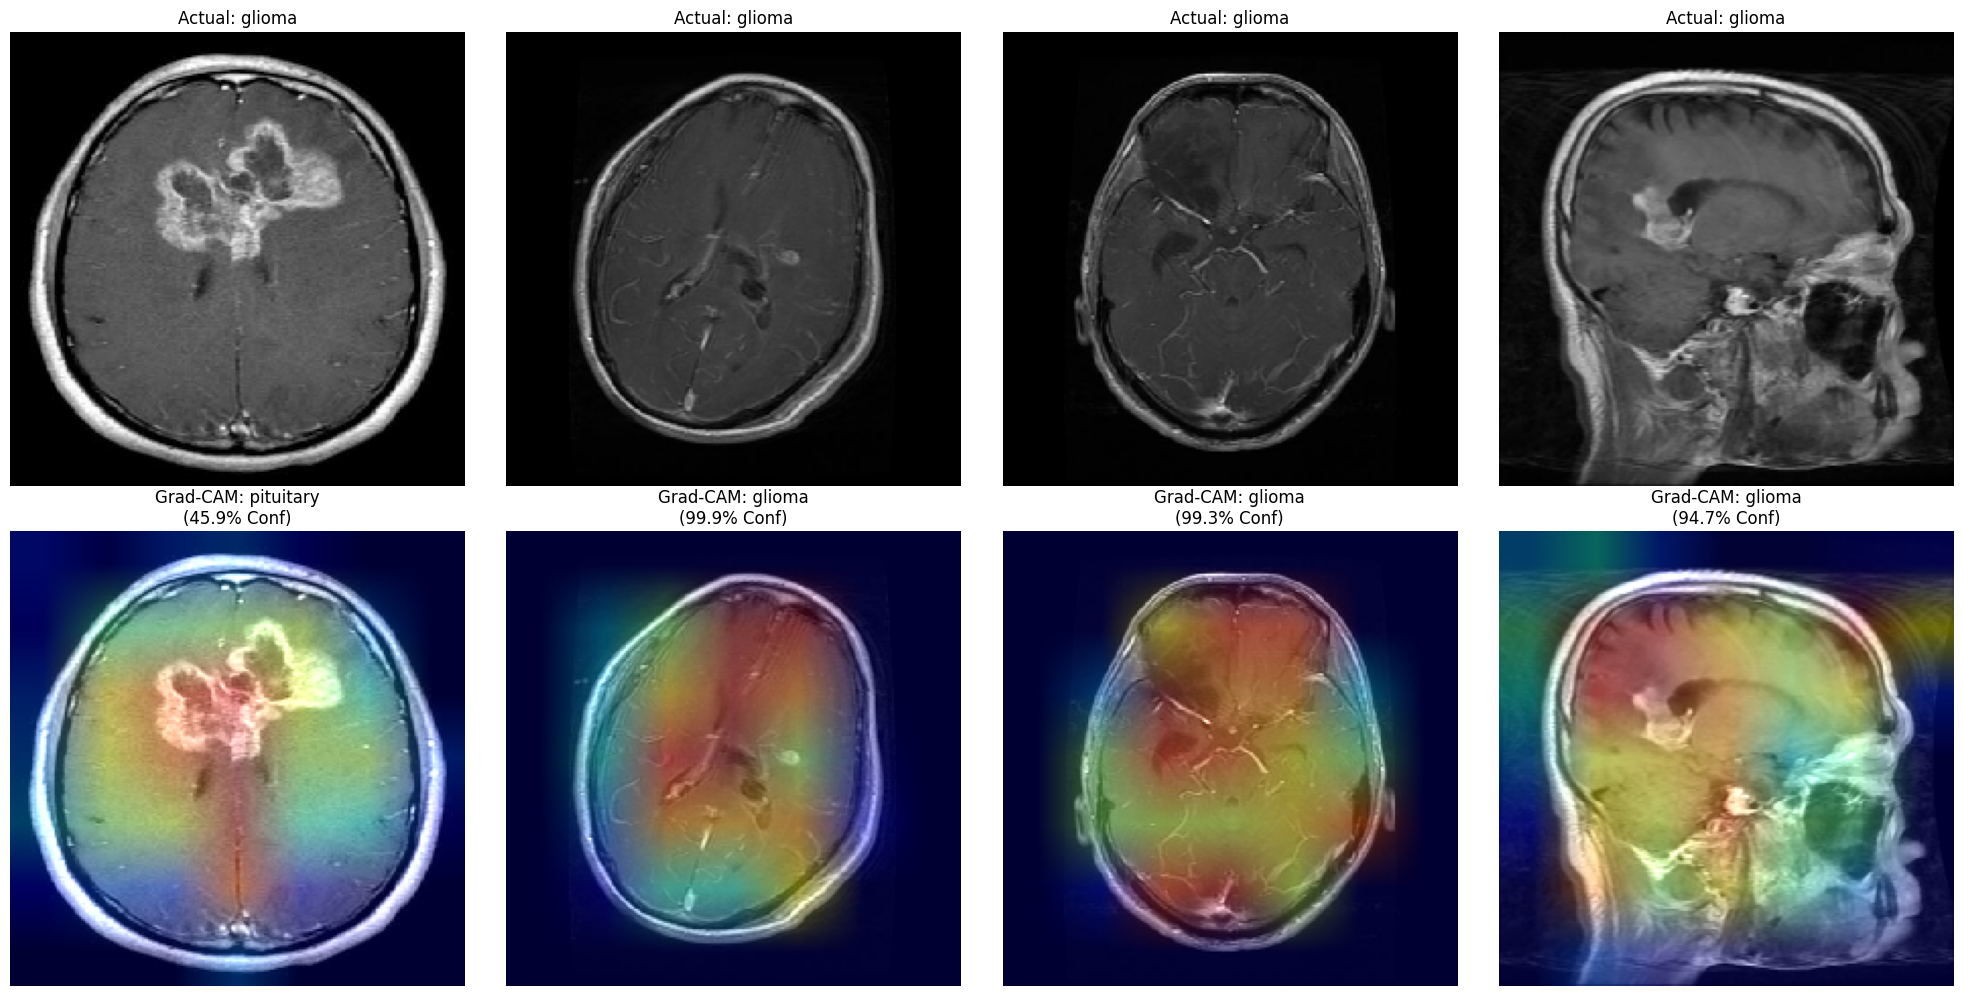

In [33]:
# Identify base model and target layer
base_model = efficientnet_model.get_layer('efficientnetb0')
LAST_CONV_LAYER = "top_activation"

os.makedirs('gradcam_results', exist_ok=True)

test_gen.reset()
x_batch, y_batch = next(test_gen)

num_examples = 4
plt.figure(figsize=(20, 10))

for i in range(num_examples):
    img_array = np.expand_dims(x_batch[i], axis=0)

    # Get prediction from the MAIN model to determine the class
    full_preds = efficientnet_model.predict(img_array)
    pred_idx = np.argmax(full_preds[0])

    # Generate heatmap using the base model
    heatmap = make_gradcam_heatmap(img_array, base_model, LAST_CONV_LAYER)

    # Prepare original image for display
    original_img = x_batch[i]
    original_img = (original_img - original_img.min()) / (original_img.max() - original_img.min())
    original_img = np.uint8(255 * original_img)

    # Overlay and display
    save_path = f"gradcam_results/sample_{i}.jpg"
    overlayed = save_and_display_gradcam(original_img, heatmap, cam_path=save_path)

    plt.subplot(2, num_examples, i + 1)
    plt.imshow(original_img)
    plt.title(f"Actual: {class_names[int(y_batch[i])]}")
    plt.axis("off")

    plt.subplot(2, num_examples, i + 1 + num_examples)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM: {class_names[pred_idx]}\n({full_preds[0][pred_idx]*100:.1f}% Conf)")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 21. Saving Project Outputs
We will now gather all our key artifacts (model, plots, and visualizations) into a single `outputs` directory for deployment or reporting.

In [34]:
import os
import shutil

# 1. Create the main outputs directory
output_dir = 'project_outputs'
os.makedirs(output_dir, exist_ok=True)

# 2. Save the Trained Model
model_path = os.path.join(output_dir, 'efficientnet_tumor_classifier.h5')
efficientnet_model.save(model_path)

# 3. Save Training History Graphs
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_eff.history['accuracy'], label='Train')
plt.plot(history_eff.history['val_accuracy'], label='Val')
plt.title('Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_eff.history['loss'], label='Train')
plt.plot(history_eff.history['val_loss'], label='Val')
plt.title('Model Loss')
plt.legend()
plt.savefig(os.path.join(output_dir, 'training_performance.png'))
plt.close()

# 4. Save Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
plt.close()

# 5. Copy Grad-CAM results to the output folder
gradcam_dest = os.path.join(output_dir, 'gradcam_visuals')
if os.path.exists('gradcam_results'):
    if os.path.exists(gradcam_dest): shutil.rmtree(gradcam_dest)
    shutil.copytree('gradcam_results', gradcam_dest)

# 6. Print Summary
print(f"--- Project Outputs Saved ---")
print(f"Model: {model_path}")
print(f"Graphs: {os.path.join(output_dir, 'training_performance.png')}")
print(f"Confusion Matrix: {os.path.join(output_dir, 'confusion_matrix.png')}")
print(f"Grad-CAM Folder: {gradcam_dest}")

--- Project Outputs Saved ---
Model: project_outputs/efficientnet_tumor_classifier.h5
Graphs: project_outputs/training_performance.png
Confusion Matrix: project_outputs/confusion_matrix.png
Grad-CAM Folder: project_outputs/gradcam_visuals


### 12. Final Dataset Preparation
We will now finalize the data generators for Training, Validation, and Testing. We assume the path for testing is adjacent to the training folder discovered earlier.

In [19]:
# 1. Define paths
# Based on the earlier detection, we know the structure has a 'Training' folder.
# We will look for a 'Testing' folder at the same level.
train_dir = dataset_path
test_dir = dataset_path.replace('Training', 'Testing')

# 2. Configure Generators with a 20% validation split for the training data
train_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. Create Training Generator
train_gen = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

# 4. Create Validation Generator
val_gen = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

# 5. Create Test Generator
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# 6. Verify and Print Statistics
print("\n--- Dataset Statistics ---")
print(f"Training Images:   {train_gen.samples}")
print(f"Validation Images: {val_gen.samples}")
print(f"Testing Images:    {test_gen.samples}")
print(f"Class Labels:      {list(train_gen.class_indices.keys())}")

# Quick verification check
if train_gen.samples > 0 and test_gen.samples > 0:
    print("\nSuccess: Data loading verified correctly!")
else:
    print("\nError: Please check if the Testing folder exists at the expected path.")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

--- Dataset Statistics ---
Training Images:   4480
Validation Images: 1120
Testing Images:    1600
Class Labels:      ['glioma', 'meningioma', 'notumor', 'pituitary']

Success: Data loading verified correctly!


### 9. Dataset Exploration
We will visualize sample images from each tumor type to understand the dataset's characteristics and confirm image preprocessing. We'll also visualize the class distribution to ensure balance.

Sample image from 'Glioma' has dimensions: (224, 224, 3)
Sample image from 'Meningioma' has dimensions: (224, 224, 3)
Sample image from 'Pituitary' has dimensions: (224, 224, 3)
Sample image from 'Notumor' has dimensions: (224, 224, 3)


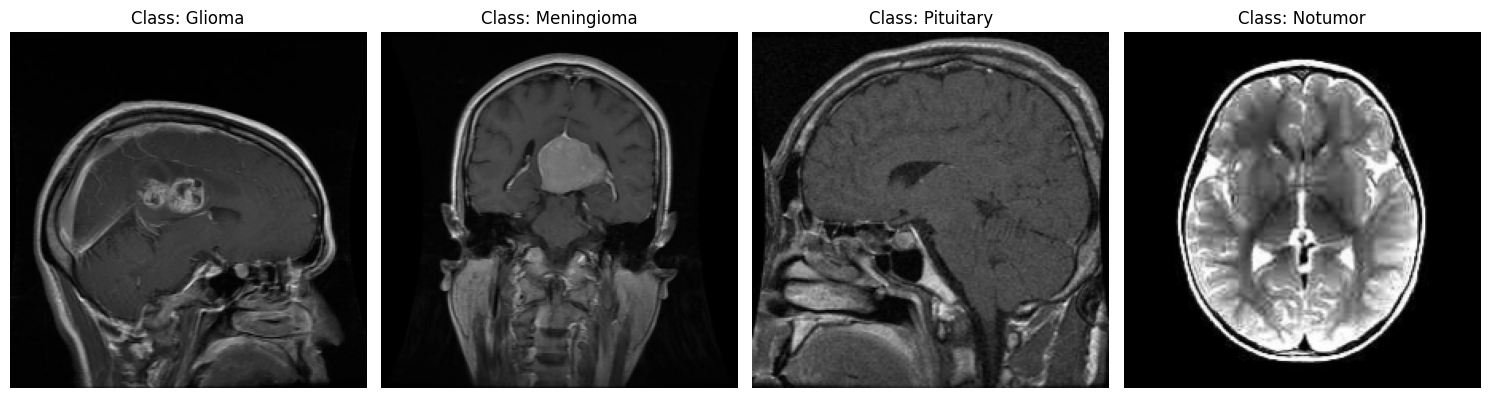

In [12]:
import random

# Set up the plot for displaying sample images
plt.figure(figsize=(15, 10))

# Loop through each class to display a sample image
for i, label in enumerate(classes):
    # Get the folder path for the current class
    class_folder = found_folders.get(label)

    if class_folder and os.path.exists(class_folder):
        # List all image files in the class folder
        all_images = [os.path.join(class_folder, f) for f in os.listdir(class_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

        if all_images:
            # Select a random image from the list
            sample_image_path = random.choice(all_images)

            # Preprocess the image using the defined function
            processed_img = preprocess_image(sample_image_path)

            # Add a subplot for each image
            plt.subplot(1, len(classes), i + 1)
            plt.imshow(processed_img)
            plt.title(f"Class: {label.capitalize()}")
            plt.axis('off')

            # Print the dimensions of the processed image
            print(f"Sample image from '{label.capitalize()}' has dimensions: {processed_img.shape}")
        else:
            print(f"No images found in folder: {class_folder}")
    else:
        print(f"Folder not found or empty for class: {label}")

plt.tight_layout()
plt.show()

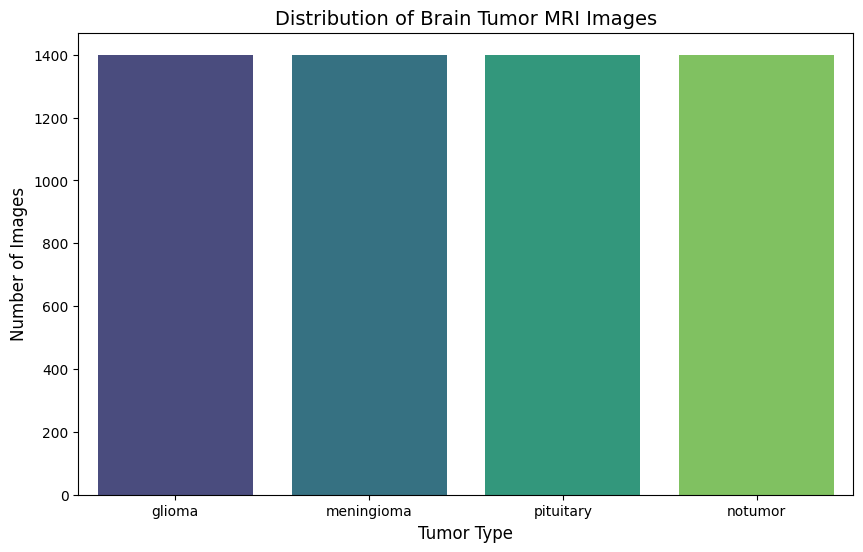


Findings from Dataset Exploration:
- We have successfully loaded and preprocessed sample images from each class.
- All images are resized to 224x224 pixels and have 3 color channels (RGB).
- The class distribution plot confirms that our dataset is balanced, with 1400 images for each of the four tumor types (glioma, meningioma, pituitary, and notumor).


In [13]:
# Re-visualize the class distribution for clarity, ensuring consistency in visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette='viridis', hue=list(image_counts.keys()), legend=False)

# Add titles and labels for clarity
plt.title('Distribution of Brain Tumor MRI Images', fontsize=14)
plt.xlabel('Tumor Type', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Display the plot
plt.show()

# Explain findings
print("\nFindings from Dataset Exploration:")
print("- We have successfully loaded and preprocessed sample images from each class.")
print(f"- All images are resized to {IMG_HEIGHT}x{IMG_WIDTH} pixels and have 3 color channels (RGB).")
print("- The class distribution plot confirms that our dataset is balanced, with 1400 images for each of the four tumor types (glioma, meningioma, pituitary, and notumor).")

### 10. EfficientNetB0 Preprocessing and Data Generators
This section prepares the data specifically for the EfficientNetB0 architecture, including specialized normalization and data augmentation.

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# 1. Define Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Initialize ImageDataGenerator
# We include validation_split here to automatically separate our data
# EfficientNet's preprocess_input handles normalization according to the model's requirements
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Normalizes specifically for EfficientNet
    validation_split=0.2,                   # Reserves 20% of the data for validation
    rotation_range=15,                      # Augmentation: random rotations
    width_shift_range=0.1,                  # Augmentation: horizontal shifts
    height_shift_range=0.1,                 # Augmentation: vertical shifts
    shear_range=0.1,                        # Augmentation: shearing transformations
    zoom_range=0.1,                         # Augmentation: random zoom
    horizontal_flip=True,                   # Augmentation: horizontal flips
    fill_mode='nearest'                     # Strategy for filling newly created pixels
)

# 3. Create Training Generator
train_generator = datagen.flow_from_directory(
    dataset_path,                           # Path to the dataset folder
    target_size=IMG_SIZE,                   # Resize all images to 224x224
    batch_size=BATCH_SIZE,                  # Group images into batches of 32
    class_mode='sparse',                    # Use sparse labels (0, 1, 2, 3)
    subset='training',                      # Set as training data
    shuffle=True                            # Shuffle for better training convergence
)

# 4. Create Validation Generator
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',                    # Set as validation data
    shuffle=False                           # No need to shuffle validation data
)

print(f"Data generators created. Classes found: {list(train_generator.class_indices.keys())}")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Data generators created. Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']


### 11. Advanced Data Augmentation
To improve model robustness and prevent overfitting, we apply random transformations to the training data. This ensures the model learns invariant features of brain tumors regardless of their orientation or brightness.

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the ImageDataGenerator with augmentation parameters
# These transformations help the model generalize better to unseen clinical data
augmentation_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values between 0 and 1
    rotation_range=20,         # Randomly rotate images by up to 20 degrees
    width_shift_range=0.1,     # Randomly shift images horizontally by 10%
    height_shift_range=0.1,    # Randomly shift images vertically by 10%
    brightness_range=[0.8, 1.2], # Adjust brightness between 80% and 120%
    zoom_range=0.1,            # Randomly zoom in/out by 10%
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='nearest'        # Strategy for filling in pixels created by shifts
)

print("Data augmentation pipeline configured successfully.")

Data augmentation pipeline configured successfully.


#### Visualizing Augmented Samples
Let's see how a single MRI image looks after passing through the augmentation pipeline multiple times.

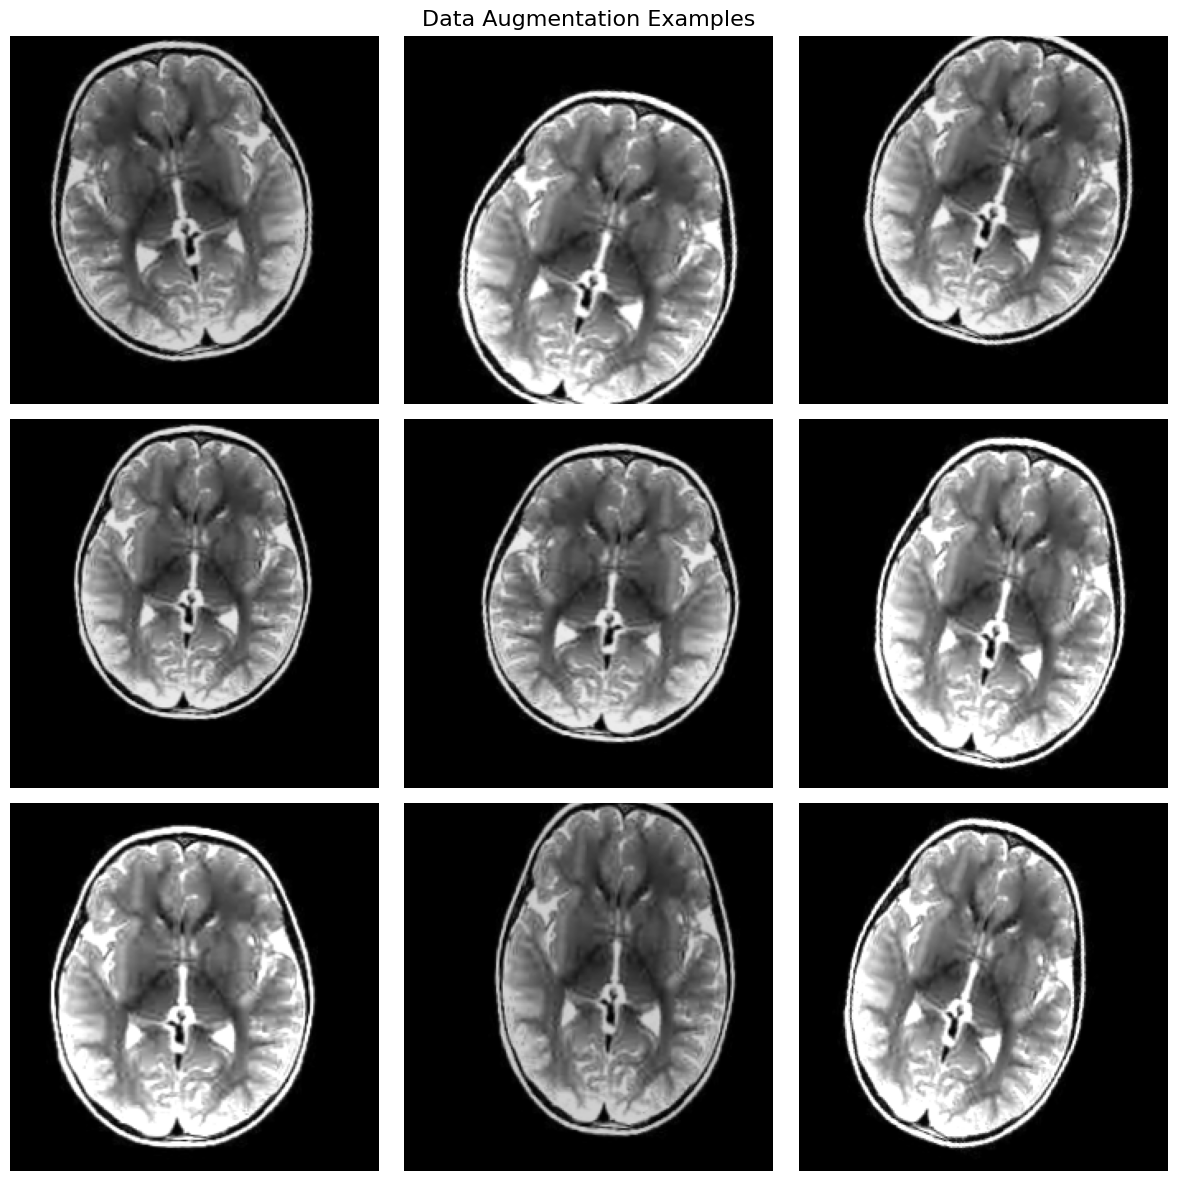

In [18]:
# Use a sample image from the dataset for visualization
# sample_image_path was defined during the exploration phase
img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))

# Reshape to (1, 224, 224, 3) as expected by the generator
img_array = np.expand_dims(img, 0)

# Create a figure to display 9 augmented versions of the same image
plt.figure(figsize=(12, 12))
plt.suptitle("Data Augmentation Examples", fontsize=16)

i = 0
# Generate and plot 9 random augmentations
for batch in augmentation_datagen.flow(img_array, batch_size=1):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch[0])
    plt.axis('off')
    i += 1
    if i % 9 == 0:
        break

plt.tight_layout()
plt.show()

### 11. Data Augmentation and Visualization
To prevent overfitting and help the model generalize to different scan angles and conditions, we apply various transformations to our training data.

In [15]:
# Initialize the ImageDataGenerator with specific augmentation parameters
augmentation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Maintain EfficientNet normalization
    rotation_range=20,                       # Randomly rotate images up to 20 degrees
    width_shift_range=0.1,                   # Randomly shift images horizontally (10% of width)
    height_shift_range=0.1,                  # Randomly shift images vertically (10% of height)
    brightness_range=[0.8, 1.2],             # Randomly adjust brightness between 80% and 120%
    shear_range=0.1,                         # Apply random shearing transformations
    zoom_range=0.1,                          # Randomly zoom inside pictures
    horizontal_flip=True,                    # Randomly flip images horizontally
    fill_mode='nearest'                      # Strategy for filling in new pixels created by shifts/rotation
)

print("Augmentation pipeline initialized.")

Augmentation pipeline initialized.


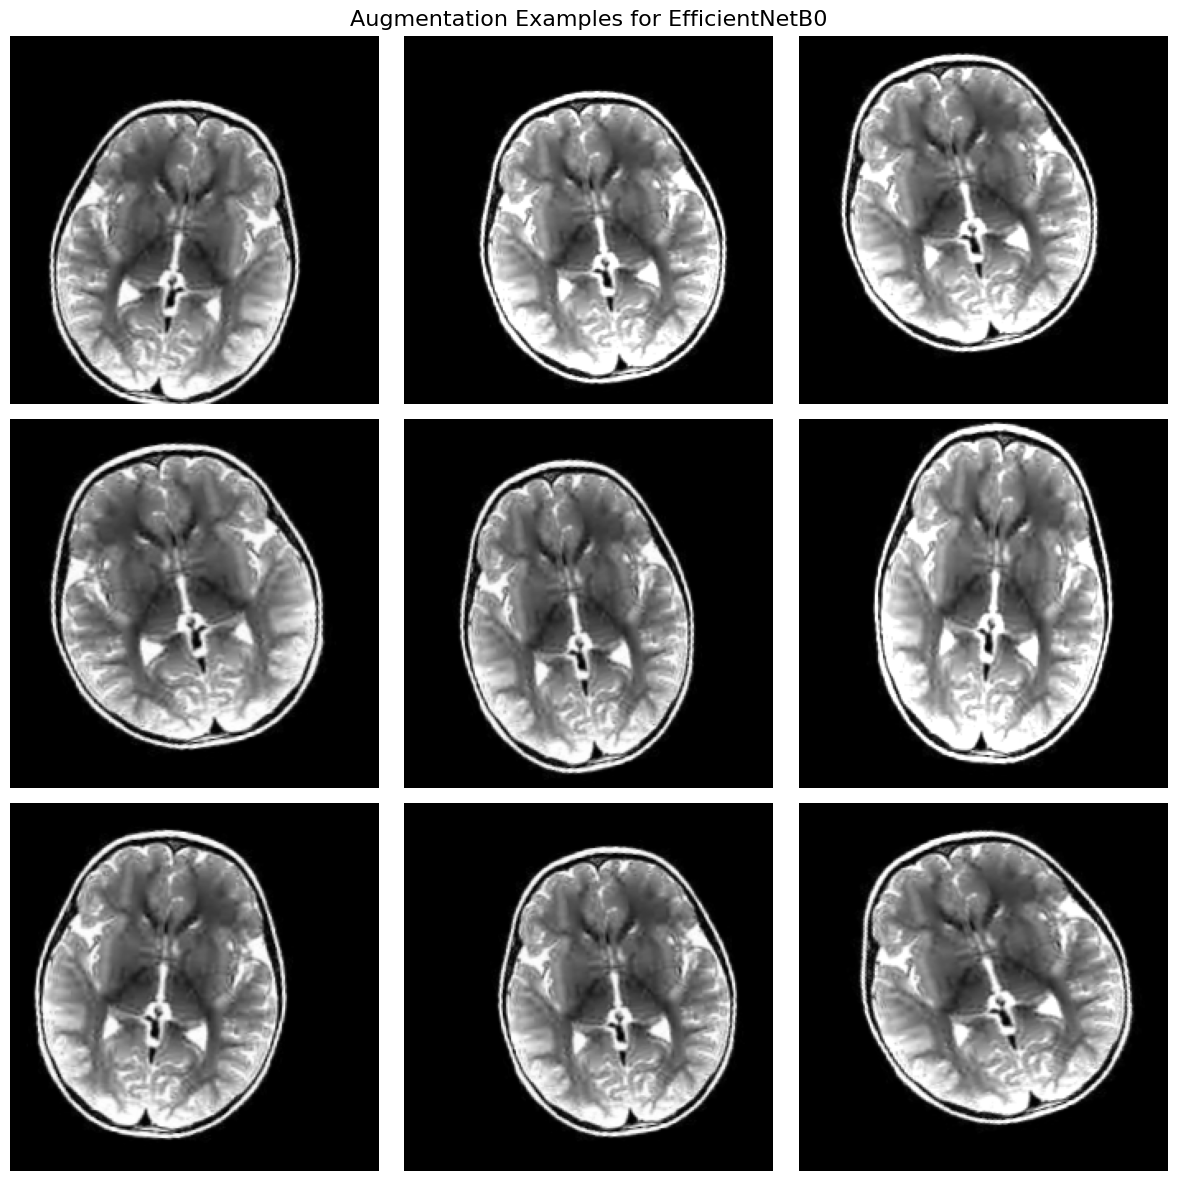

In [16]:
# Visualize the augmentation effect on a single sample image
sample_path = sample_image_path # Using the random path selected in exploration
img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

# Reshape image for the generator (1, 224, 224, 3)
img_batch = np.expand_dims(img, 0)

# Create a grid of augmented images
plt.figure(figsize=(12, 12))
plt.suptitle("Augmentation Examples for EfficientNetB0", fontsize=16)

i = 0
# The .flow() command generates batches of randomly transformed images
for batch in augmentation_datagen.flow(img_batch, batch_size=1):
    plt.subplot(3, 3, i + 1)
    # EfficientNet preprocessing might shift values; we clip/scale for visualization
    display_img = batch[0]
    # Simple scaling back to 0-1 for display purposes
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
    plt.imshow(display_img)
    plt.axis('off')
    i += 1
    if i % 9 == 0:
        break
plt.tight_layout()
plt.show()